In [3]:

!pip install -q pandas matplotlib scipy seaborn

import io, zipfile, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import files

print("Upload the historical data CSV and the fear_greed_index CSV when prompted.")
uploaded = files.upload()
print("Uploaded files:")
for fn in uploaded.keys():
    print("-", fn)

hist_file = next((f for f in uploaded if "histor" in f.lower() or "history" in f.lower() or "hyper" in f.lower()), None)
fg_file   = next((f for f in uploaded if "fear" in f.lower() or "greed" in f.lower() or "fear_greed" in f.lower()), None)

files_list = list(uploaded.keys())
if not hist_file and len(files_list) >= 1: hist_file = files_list[0]
if not fg_file and len(files_list) >= 2: fg_file = files_list[1] if files_list[1] != hist_file else files_list[0]

print("Using:")
print(" historical:", hist_file)
print(" fear/greed:", fg_file)

hist = pd.read_csv(io.BytesIO(uploaded[hist_file]), low_memory=False)
fg   = pd.read_csv(io.BytesIO(uploaded[fg_file]), low_memory=False)

print("Historical rows,cols:", hist.shape)
print("Fear/Greed rows,cols:", fg.shape)


Upload the historical data CSV and the fear_greed_index CSV when prompted.


Saving historical_data.csv to historical_data (1).csv
Saving fear_greed_index.csv to fear_greed_index (1).csv
Uploaded files:
- historical_data (1).csv
- fear_greed_index (1).csv
Using:
 historical: historical_data (1).csv
 fear/greed: fear_greed_index (1).csv
Historical rows,cols: (211224, 16)
Fear/Greed rows,cols: (2644, 4)


In [4]:

time_col = None
for c in hist.columns:
    if c.lower() in ("time","timestamp","date","datetime","created_at"):
        time_col = c; break
if not time_col:
    for c in hist.columns:
        sample = str(hist[c].iloc[0]) if hist.shape[0]>0 else ""
        if any(ch.isdigit() for ch in sample) and ("-" in sample or "/" in sample):
            time_col = c; break
if not time_col:
    raise SystemExit("Couldn't automatically find a datetime column in historical data. Rename it to include 'time' or 'date' and re-run.")

hist[time_col] = pd.to_datetime(hist[time_col], errors="coerce", infer_datetime_format=True)
hist['date'] = hist[time_col].dt.date

fg_date_col = next((c for c in fg.columns if c.lower() in ("date","day","timestamp","datetime")), fg.columns[0])
fg[fg_date_col] = pd.to_datetime(fg[fg_date_col], errors="coerce", infer_datetime_format=True)
fg['date'] = fg[fg_date_col].dt.date

class_col = next((c for c in fg.columns if any(k in c.lower() for k in ("class","fear","greed","label"))), None)
if class_col is None:
    class_col = fg.columns[1] if len(fg.columns)>1 else fg.columns[0]
fg['Sentiment'] = fg[class_col].astype(str).str.strip().str.capitalize()
fg_sent = fg[['date','Sentiment']].drop_duplicates().reset_index(drop=True)

possible_pnl = [c for c in hist.columns if 'pnl' in c.lower() or 'profit' in c.lower() or 'closed' in c.lower()]
possible_lev = [c for c in hist.columns if 'leverage' in c.lower() or 'lev' in c.lower()]
possible_size= [c for c in hist.columns if 'size' in c.lower() or 'qty' in c.lower() or 'volume' in c.lower()]
possible_acct= [c for c in hist.columns if c.lower() in ('account','acct','user','trader') or 'account' in c.lower()]
possible_side= [c for c in hist.columns if c.lower() in ('side','direction')]

print("Detected candidates:")
print(" PnL:", possible_pnl)
print(" Leverage:", possible_lev)
print(" Size:", possible_size)
print(" Account:", possible_acct)
print(" Side:", possible_side)

pnl_col  = possible_pnl[0] if possible_pnl else None
lev_col  = possible_lev[0] if possible_lev else None
size_col = possible_size[0] if possible_size else None
acct_col = possible_acct[0] if possible_acct else None
side_col = possible_side[0] if possible_side else None

if pnl_col: hist[pnl_col] = pd.to_numeric(hist[pnl_col], errors='coerce')
if lev_col: hist[lev_col] = pd.to_numeric(hist[lev_col], errors='coerce')
if size_col: hist[size_col] = pd.to_numeric(hist[size_col], errors='coerce')

if pnl_col:
    hist['win'] = hist[pnl_col] > 0
else:
    hist['win'] = np.nan

agg = {}
if pnl_col: agg[pnl_col] = ['sum','mean','median']
if size_col: agg[size_col] = ['sum','mean']
if 'win' in hist.columns: agg['win'] = ['mean']
if lev_col: agg[lev_col] = ['mean']

daily = hist.groupby('date').agg(agg)
daily.columns = ['_'.join(col).strip() for col in daily.columns.values]
daily = daily.reset_index()
daily['trade_count'] = hist.groupby('date').size().values
daily['date'] = pd.to_datetime(daily['date']).dt.date

merged = daily.merge(fg_sent, on='date', how='left')
merged['Sentiment'] = merged['Sentiment'].fillna('Unknown')

merged.to_csv('daily_aggregated_metrics.csv', index=False)
print("Saved: daily_aggregated_metrics.csv (rows: {})".format(merged.shape[0]))
merged.head()


/tmp/ipython-input-1202963650.py:15: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  hist[time_col] = pd.to_datetime(hist[time_col], errors="coerce", infer_datetime_format=True)
/tmp/ipython-input-1202963650.py:20: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  fg[fg_date_col] = pd.to_datetime(fg[fg_date_col], errors="coerce", infer_datetime_format=True)


Detected candidates:
 PnL: ['Closed PnL']
 Leverage: []
 Size: ['Size Tokens', 'Size USD']
 Account: ['Account']
 Side: ['Side', 'Direction']
Saved: daily_aggregated_metrics.csv (rows: 5)


,date,Closed PnL_sum,Closed PnL_mean,Closed PnL_median,Size Tokens_sum,Size Tokens_mean,win_mean,trade_count,Sentiment
0,1970-01-01,1.029696e+07,48.749001,0.0,9.765656e+08,4623.364979,0.411265,211224,Fear
1,1970-01-01,1.029696e+07,48.749001,0.0,9.765656e+08,4623.364979,0.411265,211224,Extreme fear
2,1970-01-01,1.029696e+07,48.749001,0.0,9.765656e+08,4623.364979,0.411265,211224,Neutral
3,1970-01-01,1.029696e+07,48.749001,0.0,9.765656e+08,4623.364979,0.411265,211224,Greed
4,1970-01-01,1.029696e+07,48.749001,0.0,9.765656e+08,4623.364979,0.411265,211224,Extreme greed


Group means by Sentiment:
               Closed PnL_sum  Closed PnL_mean  Closed PnL_median  \
Sentiment                                                           
Extreme fear     1.029696e+07           48.749                0.0   
Extreme greed    1.029696e+07           48.749                0.0   
Fear             1.029696e+07           48.749                0.0   
Greed            1.029696e+07           48.749                0.0   
Neutral          1.029696e+07           48.749                0.0   

               Size Tokens_sum  Size Tokens_mean  win_mean  trade_count  
Sentiment                                                                
Extreme fear      9.765656e+08          4623.365    0.4113     211224.0  
Extreme greed     9.765656e+08          4623.365    0.4113     211224.0  
Fear              9.765656e+08          4623.365    0.4113     211224.0  
Greed             9.765656e+08          4623.365    0.4113     211224.0  
Neutral           9.765656e+08          4623.3

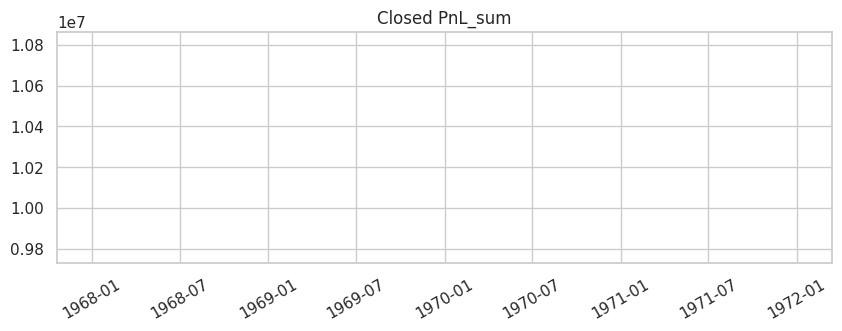

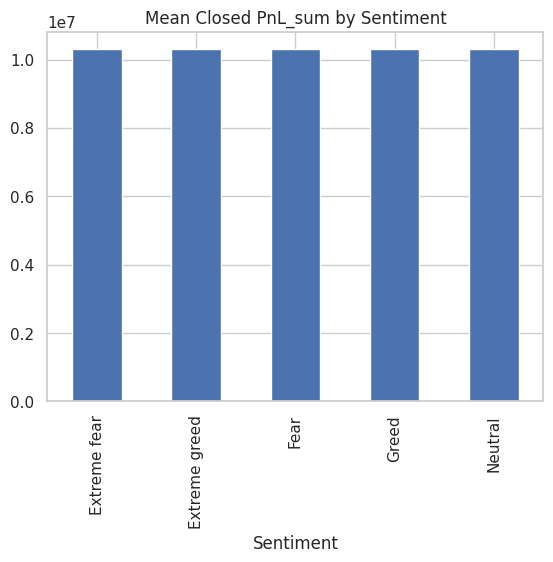

N Fear days: 2 N Greed days: 2
t-test: t=nan, p=nan
Mann-Whitney U p-value: 1.0


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [5]:

import seaborn as sns
sns.set(style="whitegrid")

print("Group means by Sentiment:")
print(merged.groupby('Sentiment').mean(numeric_only=True).round(4))


num_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
pnl_col_candidate = next((c for c in num_cols if 'pnl' in c.lower() or 'profit' in c.lower()), (num_cols[0] if num_cols else None))
if pnl_col_candidate:
    plt.figure(figsize=(10,3)); plt.plot(pd.to_datetime(merged['date']), merged[pnl_col_candidate]); plt.title(pnl_col_candidate); plt.xticks(rotation=30); plt.show()

if pnl_col_candidate:
    merged.groupby('Sentiment')[pnl_col_candidate].mean().plot(kind='bar', title='Mean {} by Sentiment'.format(pnl_col_candidate))
    plt.show()

fear_vals = merged.loc[merged['Sentiment'].str.contains('Fear', case=False, na=False), pnl_col_candidate].dropna()
greed_vals = merged.loc[merged['Sentiment'].str.contains('Greed', case=False, na=False), pnl_col_candidate].dropna()
print("N Fear days:", len(fear_vals), "N Greed days:", len(greed_vals))
if len(fear_vals)>1 and len(greed_vals)>1:
    tstat, pval = stats.ttest_ind(fear_vals, greed_vals, equal_var=False, nan_policy='omit')
    print("t-test: t=%.4f, p=%.4f" % (tstat, pval))

    try:
        u_stat, p_mw = stats.mannwhitneyu(fear_vals, greed_vals, alternative='two-sided')
        print("Mann-Whitney U p-value:", p_mw)
    except Exception as e:
        print("Mann-Whitney failed:", e)
else:
    print("Too few Fear/Greed days for a reliable test — consider weekly aggregation or numeric sentiment score.")


In [6]:

report = """# Trader Behavior Insights — Quick Report

Generated programmatically in Colab.

Files:
- daily_aggregated_metrics.csv
"""
with open('report.md','w') as f: f.write(report)

with zipfile.ZipFile('assignment_package.zip','w') as zf:
    zf.write('daily_aggregated_metrics.csv')
    zf.write('report.md')

files.download('assignment_package.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>